**Installing XGBoost**
======================

In [25]:
!pip install xgboost

**Importing libraries, evaluation metrics and functions**
=========================================

In [38]:
import pandas as pd
import numpy as np
import joblib

from xgboost import plot_importance
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    average_precision_score
)
from xgboost import XGBClassifier

Load the dataset and keep fraud relevant transactions
=========================================

In [27]:
df = pd.read_csv("PS_20174392719_1491204439457_log.csv.zip")
print(df.shape)
df.head()
df = df[df["type"].isin(["TRANSFER","CASH_OUT"])]

(6362620, 11)


Feature Engineering
===================

In [28]:
df["errorBalanceOrig"] = (
    df["newbalanceOrig"]
    + df["amount"]
    - df["oldbalanceOrg"]
)
df["errorBalanceDest"] = (
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
)
df["hourOfDay"] = df["step"] % 24
df["origEmptied"] = (
    df["newbalanceOrig"] == 0
).astype(int)

Encode Type ( text to numbers)
===========

In [29]:
df = pd.get_dummies(
    df,
    columns=["type"],
    drop_first=True
)

Remove Names
============

In [30]:
df.drop(
    ["nameOrig","nameDest"],
    axis=1,
    inplace=True
)

Train-Test Split
================

In [31]:
df.drop("isFlaggedFraud", axis=1, inplace=True)
X = df.drop("isFraud", axis=1)
y = df["isFraud"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Handle Class Imbalance
======================

In [32]:
scale_pos_weight = (
    len(y_train[y_train==0]) /
    len(y_train[y_train==1])
)
print(scale_pos_weight)

336.34048706240486


Train XGBoost model
===================

In [33]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

Predictions
===========

In [34]:
probs = model.predict_proba(X_test)[:,1]
pred = (probs > 0.5).astype(int)

Threshold and metrics
=====================




In [35]:
pred = (probs > 0.4).astype(int)

print("Precision:",
      precision_score(y_test,pred))
print("Recall:",
      recall_score(y_test,pred))
print("F1:",
      f1_score(y_test,pred))
print("ROC-AUC:",
      roc_auc_score(y_test,probs))
print("PR-AUC:",
      average_precision_score(y_test, probs))

Precision: 0.9909310761789601
Recall: 0.9975654290931223
F1: 0.9942371853199878
ROC-AUC: 0.9988795787509562
PR-AUC: 0.9981425022498863


Confusion Matrix
================

In [36]:
print(confusion_matrix(y_test,pred))

[[552424     15]
 [     4   1639]]


Checks
======

In [37]:
print(X.columns.tolist())

['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'hourOfDay', 'origEmptied', 'type_TRANSFER']


Save model
===========

In [42]:
joblib.dump(model, "xgboost.pkl")

['xgboost.pkl']

Feature importance chart and Table
==================================

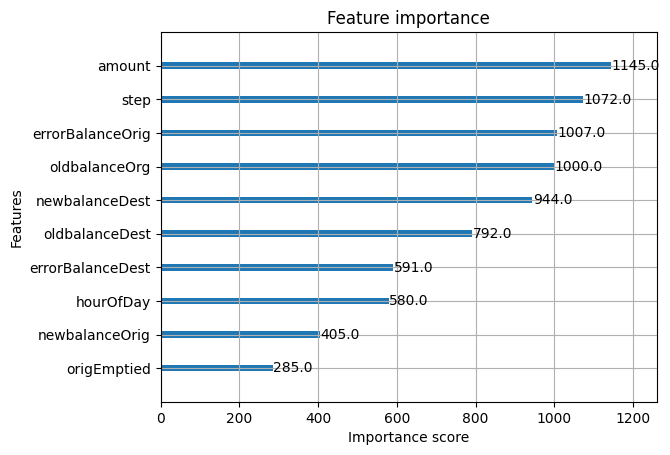

             Feature  Importance
6   errorBalanceOrig    0.490680
9        origEmptied    0.257606
2      oldbalanceOrg    0.092311
3     newbalanceOrig    0.078046
1             amount    0.033952
5     newbalanceDest    0.017947
7   errorBalanceDest    0.009355
10     type_TRANSFER    0.008547
4     oldbalanceDest    0.004073
8          hourOfDay    0.003913


In [41]:
plot_importance(model, max_num_features=10)
plt.show()

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))